In [2]:
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import pandas as pd

# import seaborn as sns
import ast

import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
import random

In [69]:

time_interval = 100
prob_de_cair = 0.05

servers = [x for x in range(12)]
servers_disponiveis = [x for x in servers]  # Servidores disponíveis inicialmente são todos
total_falhas = 0  # Contador para o total de falhas ao longo de toda a simulação

for j in range(int(1000 / time_interval)):
    servidores_falharam_no_intervalo = []  # Lista para armazenar servidores que falharam no intervalo atual

    for server in list(
        servers_disponiveis
    ):  # Itera sobre uma cópia da lista de servidores disponíveis
        if random.random() < prob_de_cair:
            servers_disponiveis.remove(
                server
            )  # Remove o servidor da lista de disponíveis permanentemente
            servidores_falharam_no_intervalo.append(server)
            total_falhas += 1

    print(
        f"Total de servidores derrubados neste intervalo: {len(servidores_falharam_no_intervalo)},{servidores_falharam_no_intervalo}"
    )

print(f"Total de falhas durante toda a simulação: {total_falhas}")

Total de servidores derrubados neste intervalo: 2,[1, 10]
Total de servidores derrubados neste intervalo: 1,[0]
Total de servidores derrubados neste intervalo: 1,[7]
Total de servidores derrubados neste intervalo: 0,[]
Total de servidores derrubados neste intervalo: 1,[3]
Total de servidores derrubados neste intervalo: 0,[]
Total de servidores derrubados neste intervalo: 1,[11]
Total de servidores derrubados neste intervalo: 1,[6]
Total de servidores derrubados neste intervalo: 1,[4]
Total de servidores derrubados neste intervalo: 2,[8, 9]
Total de falhas durante toda a simulação: 10


In [70]:
import random


def derruba_servers_simu(repeat=30, prob_de_cair=0.05, time_interval=100):
    array_falhas = []

    for k in range(repeat):
        servers = [x for x in range(12)]
        servers_disponiveis = [x for x in servers]  # Servidores disponíveis inicialmente são todos
        total_falhas = 0  # Contador para o total de falhas ao longo de toda a simulação

        for j in range(int(1000 / time_interval)):
            servidores_falharam_no_intervalo = []  # Lista para armazenar servidores que falharam no intervalo atual

            for server in list(
                servers_disponiveis
            ):  # Itera sobre uma cópia da lista de servidores disponíveis
                if random.random() < prob_de_cair:
                    servers_disponiveis.remove(
                        server
                    )  # Remove o servidor da lista de disponíveis permanentemente
                    servidores_falharam_no_intervalo.append(server)
                    total_falhas += 1

        #     print(f"Total de servidores derrubados neste intervalo: {len(servidores_falharam_no_intervalo)},{servidores_falharam_no_intervalo}")

        # print(f"Total de falhas durante toda a simulação: {total_falhas}")
        array_falhas.append(total_falhas)

    return array_falhas

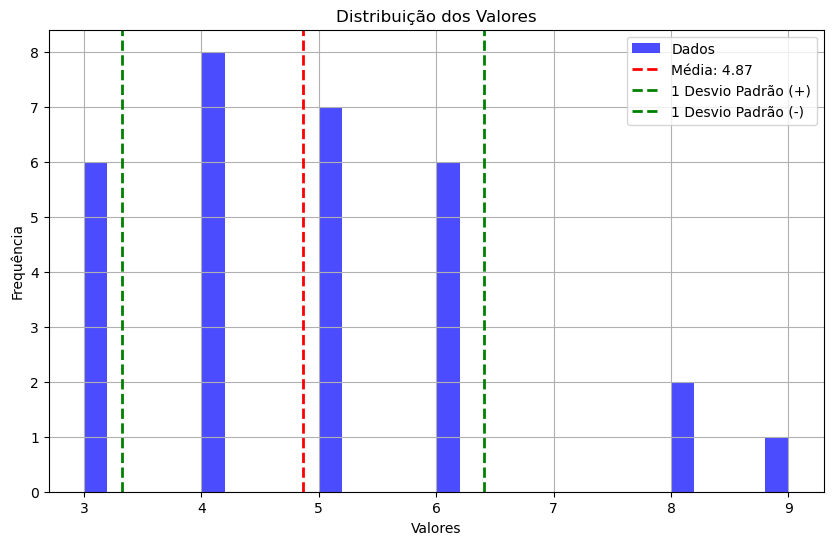

In [110]:

# Criando uma lista de valores para demonstração (distribuição normal)
data = derruba_servers_simu(repeat=30, time_interval=100, prob_de_cair=0.05)
# Cálculo da média e da variância
mean = np.mean(data)
variance = np.var(data)

# Criando o histograma para visualizar a distribuição
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, alpha=0.7, color="blue", label="Dados")
plt.axvline(mean, color="red", linestyle="dashed", linewidth=2, label=f"Média: {mean:.2f}")
plt.axvline(
    mean + np.sqrt(variance),
    color="green",
    linestyle="dashed",
    linewidth=2,
    label="1 Desvio Padrão (+)",
)
plt.axvline(
    mean - np.sqrt(variance),
    color="green",
    linestyle="dashed",
    linewidth=2,
    label="1 Desvio Padrão (-)",
)

plt.title("Distribuição dos Valores")
plt.xlabel("Valores")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
results_flows_directories = glob.glob("../../results_flows_*/*")
results_flows_directories

['../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,1.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,2.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,3.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,4.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,1.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,2.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,3.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,4.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,3.0,1.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,3.0,2.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,3.0,3.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,3.0,4.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,4.0,1.0]',
 '../..\\results_flows_50\\ga_35_sfc_on_sharing_y_[1.0,1.0,4.0,2.0]',
 '../..\\results_flo

In [3]:
for alg in results_flows_directories:
    print(alg)
    simu_exec_name = alg.split("/")[-1].split("_")
    alg_name = simu_exec_name[2][3:]
    sfc = simu_exec_name[3]
    share = simu_exec_name[-2]
    parameters = simu_exec_name[-1]

    print("alg name: ", alg_name)
    print("share: ", share)
    print("parameters : ", parameters)

../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,1.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,1.0,1.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,2.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,1.0,2.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,3.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,1.0,3.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,1.0,4.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,1.0,4.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,1.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,2.0,1.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,2.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,2.0,2.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,3.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,2.0,3.0]
../..\results_flows_50\ga_35_sfc_on_sharing_y_[1.0,1.0,2.0,4.0]
alg name:  ga
share:  y
parameters :  [1.0,1.0,2.0,4.0]
../..\results_flows_50\ga_35_sfc_on_shar

In [4]:
big_data = pd.DataFrame()


def colect_data_from_alg_directory(results_flows_directories):
    data_nla = []

    for alg_dir in results_flows_directories:
        simulacoes_okays = 0
        simu_exec_name = alg_dir.split("/")[-1].split("_")
        alg_name = simu_exec_name[2][3:]
        share = simu_exec_name[-2]
        parameters = simu_exec_name[-1]

        files = os.listdir(alg_dir)
        print("Simulação: ", alg_name, ",", share)
        print("Quantidade de csv: ", len(files))

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
            except:
                continue

            primeiro_tempo = simulation_df["timestamp"].values[0]
            simulation_df["tempo"] = simulation_df[["timestamp"]].applymap(
                lambda x: x - primeiro_tempo
            )
            simulation_is_success = "sfc_cache_p4_50" in simulation_df["sfc_id"].values

            if simulation_is_success:
                simulacoes_okays = simulacoes_okays + 1
                simulation_df = simulation_df[
                    [
                        "tempo",
                        "practical_cpu_utilization",
                        "cpu_utilization",
                        "cache_utilization",
                        "bandwidth_utilization",
                        "practical_bandwidth_utilization",
                        "practical_cache_utilization",
                        "success",
                        "latency",
                        "duration",
                        "running_sfcs",
                        "cpu_saved",
                        "cache_saved",
                        "shared_vnfs",
                    ]
                ]

                # Arrendondar tempo
                simulation_df["tempo"] = simulation_df["tempo"].astype(int)

                simulation_df = simulation_df.replace("None", pd.NA)

                latency_col = simulation_df[["tempo", "latency"]]
                latency_col.dropna(inplace=True)
                latency_col.loc[:, "latency"] = latency_col["latency"].astype(float)

                ###############################################
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df["success"]):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))
                simulation_df["success"] = cumulative_avg_success
                ###############################################

                simulation_df = simulation_df.groupby("tempo", as_index=False).mean(
                    numeric_only=True
                )
                latency_df = (
                    latency_col.groupby("tempo", as_index=False)
                    .mean(numeric_only=True)
                    .reset_index()
                )

                tempo_range = simulation_df["tempo"].max()
                df_mean = simulation_df.set_index("tempo").reindex(range(tempo_range + 1))
                df_mean = df_mean.fillna(method="ffill")
                df_mean = df_mean.reset_index()

                latency_df = latency_df.set_index("tempo").reindex(range(tempo_range + 1))
                latency_df = latency_df.fillna(method="ffill")
                latency_df = latency_df.reset_index()

                df_mean["Latency"] = latency_df["latency"]

                df_mean["algorithm"] = alg_name
                df_mean["parameters"] = parameters
                # print(share)
                df_mean["sharing"] = share
                df_mean = df_mean.iloc[0:1000]
                data_nla.append(df_mean)

        data_nla_f = pd.concat(data_nla)
        print("Simulações de sucesso: ", simulacoes_okays)
        print("Dados Nulos: ", data_nla_f.isnull().sum().sum())
        print()

    return data_nla_f

In [5]:
big_data = colect_data_from_alg_directory(results_flows_directories)

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nulos:  0

Simulação:  ga , y
Quantidade de csv:  1
Simulações de sucesso:  1
Dados Nul

In [6]:
# Suposições
capacidade_maxima_banda_gbps = 10  # Capacidade máxima da banda em Gbps

# Calculando métricas
big_data["eficiencia de cpu"] = big_data["cpu_utilization"] / big_data["running_sfcs"]
big_data["eficiencia de banda"] = big_data["bandwidth_utilization"] / big_data["running_sfcs"]
big_data["eficiencia de cache"] = big_data["cache_utilization"] / big_data["running_sfcs"]
big_data["bit_rate"] = big_data["practical_bandwidth_utilization"] * capacidade_maxima_banda_gbps

In [7]:
# deve manter a coluna alg se houver a analise de mais um alg
big_data = big_data.drop(["algorithm", "sharing"], axis=1)

In [8]:
big_data.groupby("parameters").mean()

,tempo,practical_cpu_utilization,cpu_utilization,cache_utilization,bandwidth_utilization,practical_bandwidth_utilization,practical_cache_utilization,success,latency,duration,running_sfcs,cpu_saved,cache_saved,shared_vnfs,Latency,eficiencia de cpu,eficiencia de banda,eficiencia de cache,bit_rate
parameters,,,,,,,,,,,,,,,,,,,
"[1.0,1.0,1.0,1.0]",499.5,0.374216,0.348560,0.331642,0.177506,0.397055,0.419325,0.953363,1.944917,0.341880,39.294033,29.003250,110.506250,23.299917,1.944917,0.008876,0.004531,0.008442,3.970551
"[1.0,1.0,1.0,2.0]",499.5,0.379635,0.357411,0.340269,0.168187,0.398127,0.435493,0.971277,1.886667,0.354568,39.949367,28.094694,101.939583,24.068833,1.886667,0.008949,0.004217,0.008554,3.981265
"[1.0,1.0,1.0,3.0]",499.5,0.370614,0.350386,0.350006,0.169508,0.379889,0.435663,0.969372,1.986400,0.351991,40.027167,32.761194,105.868750,24.399167,1.986400,0.008795,0.004270,0.008812,3.798894
"[1.0,1.0,1.0,4.0]",499.5,0.368898,0.339273,0.333724,0.170774,0.381609,0.434102,0.951076,2.000850,0.347229,38.257767,27.008000,100.025000,21.765817,2.000850,0.008928,0.004512,0.008744,3.816087
"[1.0,1.0,2.0,1.0]",499.5,0.384065,0.370415,0.359347,0.185261,0.404921,0.441208,0.976687,1.898167,0.349384,41.530667,28.954444,103.916667,24.138250,1.898167,0.008923,0.004507,0.008656,4.049212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"[3.0,3.0,4.0,2.0]",499.5,0.380923,0.368074,0.363683,0.179537,0.377255,0.455135,0.982269,2.022183,0.201253,41.349850,27.378361,102.414583,23.439817,2.022183,0.008910,0.004343,0.008854,3.772549
"[3.0,3.0,4.0,3.0]",499.5,0.372625,0.358549,0.352332,0.173749,0.376863,0.435074,0.971074,2.055367,0.197810,40.517683,29.258672,105.362083,23.344783,2.055367,0.008848,0.004295,0.008698,3.768631
"[3.0,3.0,4.0,4.0]",499.5,0.355366,0.337846,0.336721,0.168231,0.385418,0.422720,0.960695,1.923517,0.199707,38.725017,31.209889,108.779167,23.956950,1.923517,0.008726,0.004366,0.008685,3.854177


In [9]:
grouped_big_data = big_data.groupby("parameters").mean()
grouped_big_data.reset_index(inplace=True)

grouped_big_data["parameters"] = grouped_big_data["parameters"].apply(
    lambda x: ast.literal_eval(x)
)
grouped_big_data["parameters"] = grouped_big_data["parameters"].apply(
    lambda x: [int(i) for i in x]
)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculando a latência média para cada peso
# Convertendo strings de configurações em listas de inteiros para facilitar a manipulação
# grouped_big_data['parameters'] = grouped_big_data['parameters'].apply(lambda x: [float(n) for n in x.strip('[]').split(', ')])

In [11]:
grouped_big_data

,parameters,tempo,practical_cpu_utilization,cpu_utilization,cache_utilization,bandwidth_utilization,practical_bandwidth_utilization,practical_cache_utilization,success,latency,duration,running_sfcs,cpu_saved,cache_saved,shared_vnfs,Latency,eficiencia de cpu,eficiencia de banda,eficiencia de cache,bit_rate
0,"[1, 1, 1, 1]",499.5,0.374216,0.348560,0.331642,0.177506,0.397055,0.419325,0.953363,1.944917,0.341880,39.294033,29.003250,110.506250,23.299917,1.944917,0.008876,0.004531,0.008442,3.970551
1,"[1, 1, 1, 2]",499.5,0.379635,0.357411,0.340269,0.168187,0.398127,0.435493,0.971277,1.886667,0.354568,39.949367,28.094694,101.939583,24.068833,1.886667,0.008949,0.004217,0.008554,3.981265
2,"[1, 1, 1, 3]",499.5,0.370614,0.350386,0.350006,0.169508,0.379889,0.435663,0.969372,1.986400,0.351991,40.027167,32.761194,105.868750,24.399167,1.986400,0.008795,0.004270,0.008812,3.798894
3,"[1, 1, 1, 4]",499.5,0.368898,0.339273,0.333724,0.170774,0.381609,0.434102,0.951076,2.000850,0.347229,38.257767,27.008000,100.025000,21.765817,2.000850,0.008928,0.004512,0.008744,3.816087
4,"[1, 1, 2, 1]",499.5,0.384065,0.370415,0.359347,0.185261,0.404921,0.441208,0.976687,1.898167,0.349384,41.530667,28.954444,103.916667,24.138250,1.898167,0.008923,0.004507,0.008656,4.049212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,"[3, 3, 4, 2]",499.5,0.380923,0.368074,0.363683,0.179537,0.377255,0.455135,0.982269,2.022183,0.201253,41.349850,27.378361,102.414583,23.439817,2.022183,0.008910,0.004343,0.008854,3.772549
168,"[3, 3, 4, 3]",499.5,0.372625,0.358549,0.352332,0.173749,0.376863,0.435074,0.971074,2.055367,0.197810,40.517683,29.258672,105.362083,23.344783,2.055367,0.008848,0.004295,0.008698,3.768631
169,"[3, 3, 4, 4]",499.5,0.355366,0.337846,0.336721,0.168231,0.385418,0.422720,0.960695,1.923517,0.199707,38.725017,31.209889,108.779167,23.956950,1.923517,0.008726,0.004366,0.008685,3.854177
170,"[3, 4, 1, 1]",499.5,0.383200,0.358924,0.350830,0.169019,0.386418,0.435286,0.969590,2.031317,0.202335,40.311500,26.623167,103.554167,23.238417,2.031317,0.008900,0.004181,0.008705,3.864182


In [12]:
df_expandido = grouped_big_data.explode("parameters")
df_expandido["Peso"] = df_expandido.groupby("parameters").cumcount() + 1
df_expandido["ValorPeso"] = df_expandido["parameters"].astype(int)

# Análise na variação dos hiperparametros nas métricas

Analisando a métrica: cpu_utilization


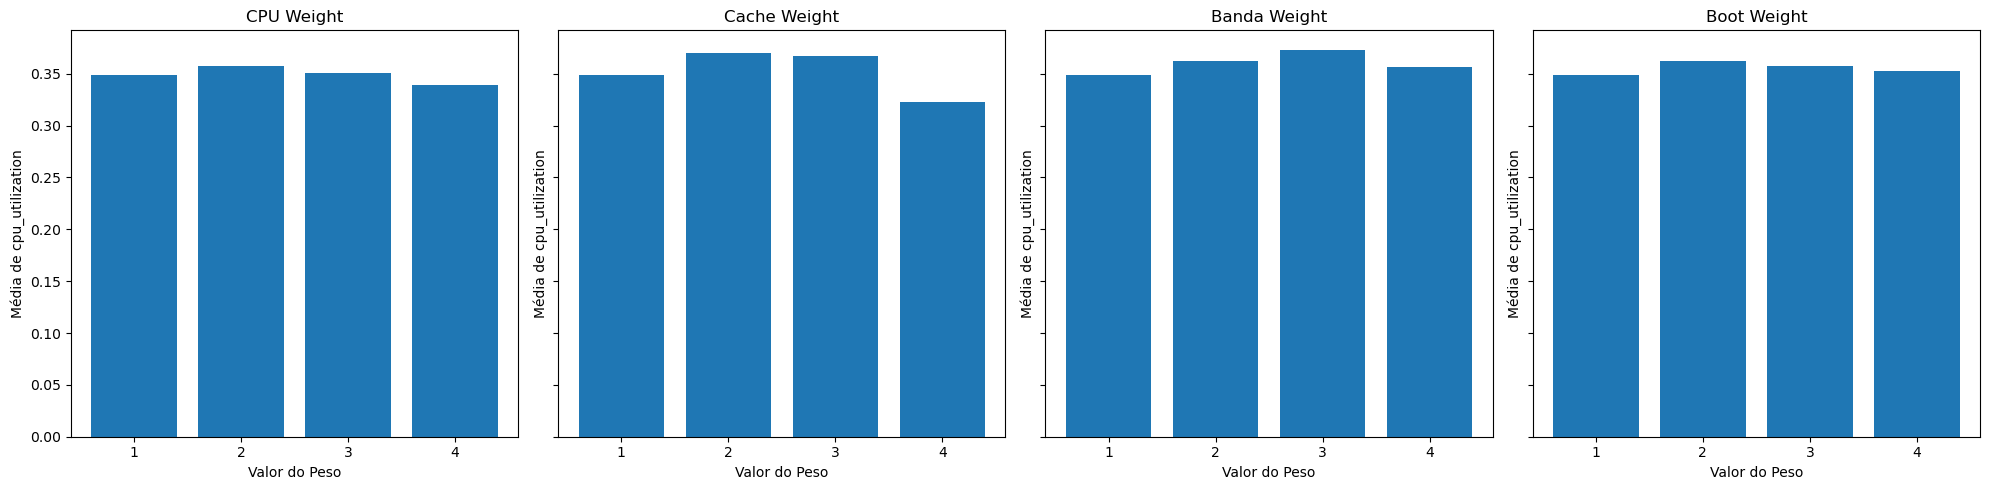

Analisando a métrica: cache_utilization


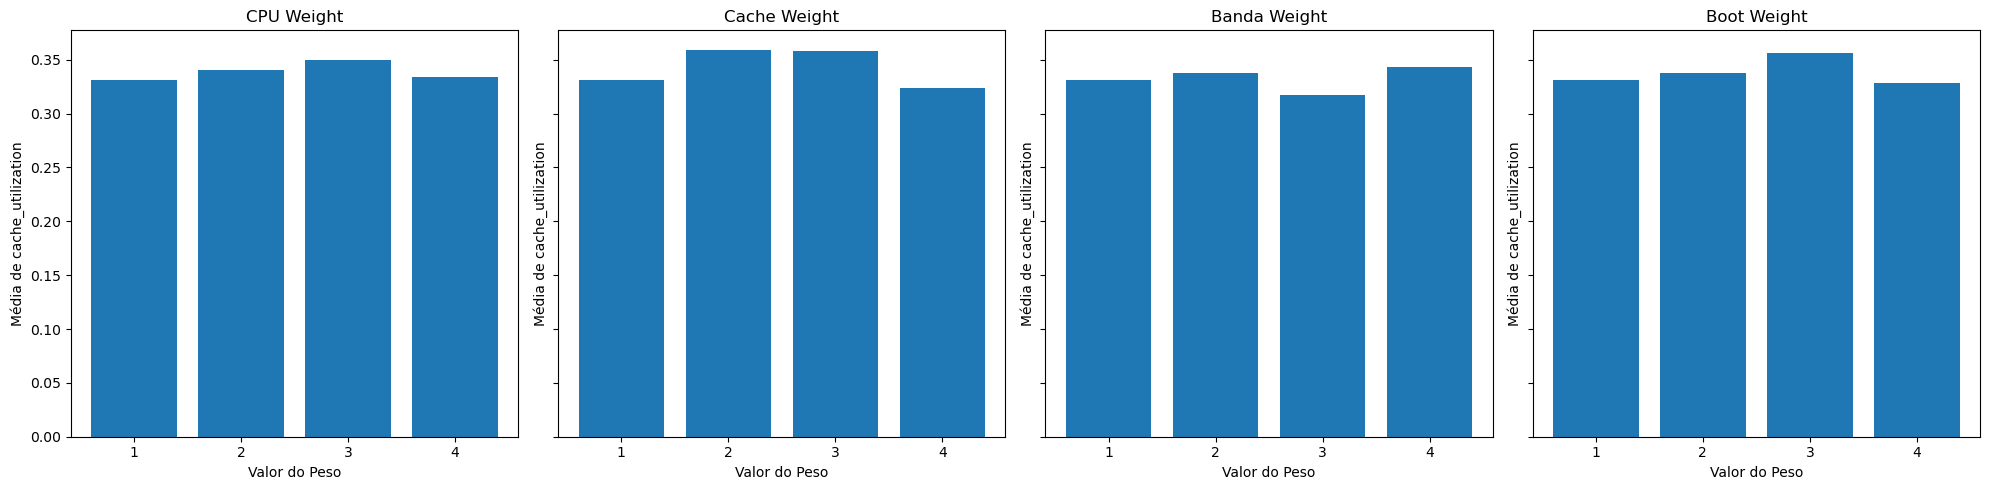

Analisando a métrica: bandwidth_utilization


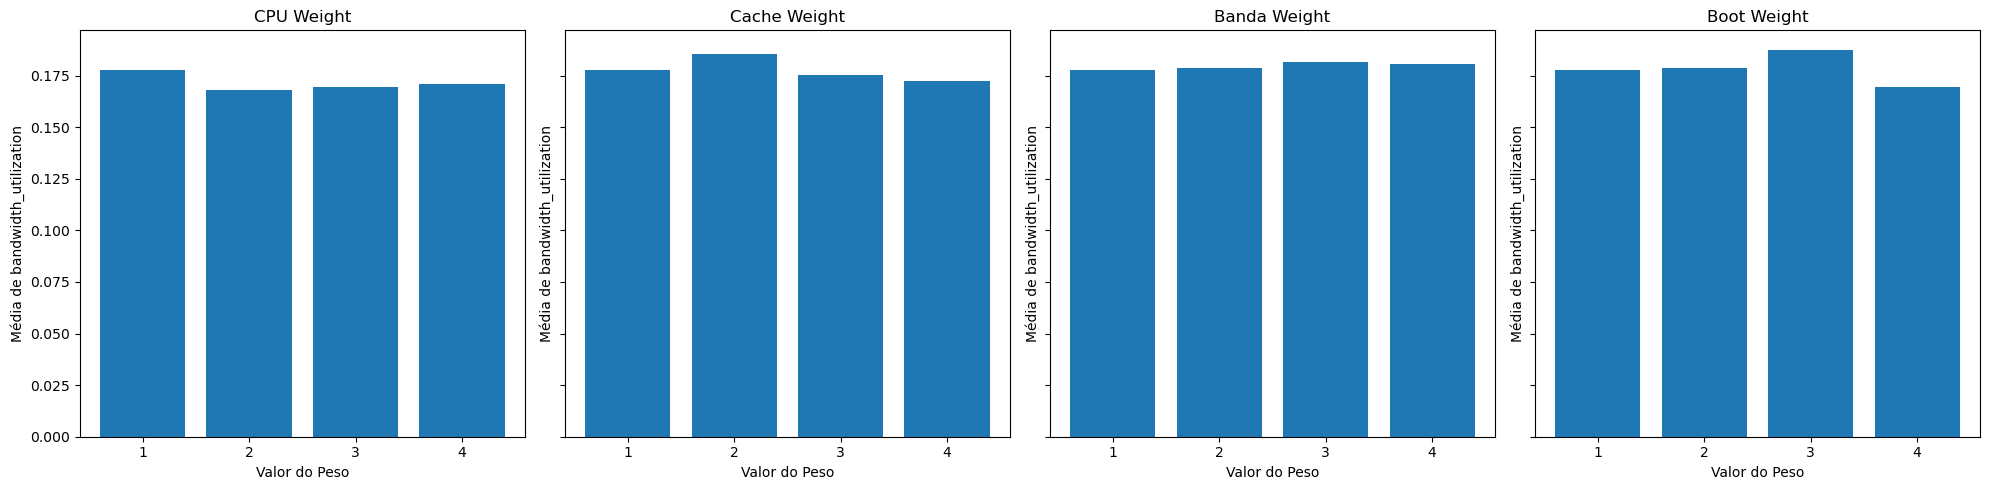

Analisando a métrica: success


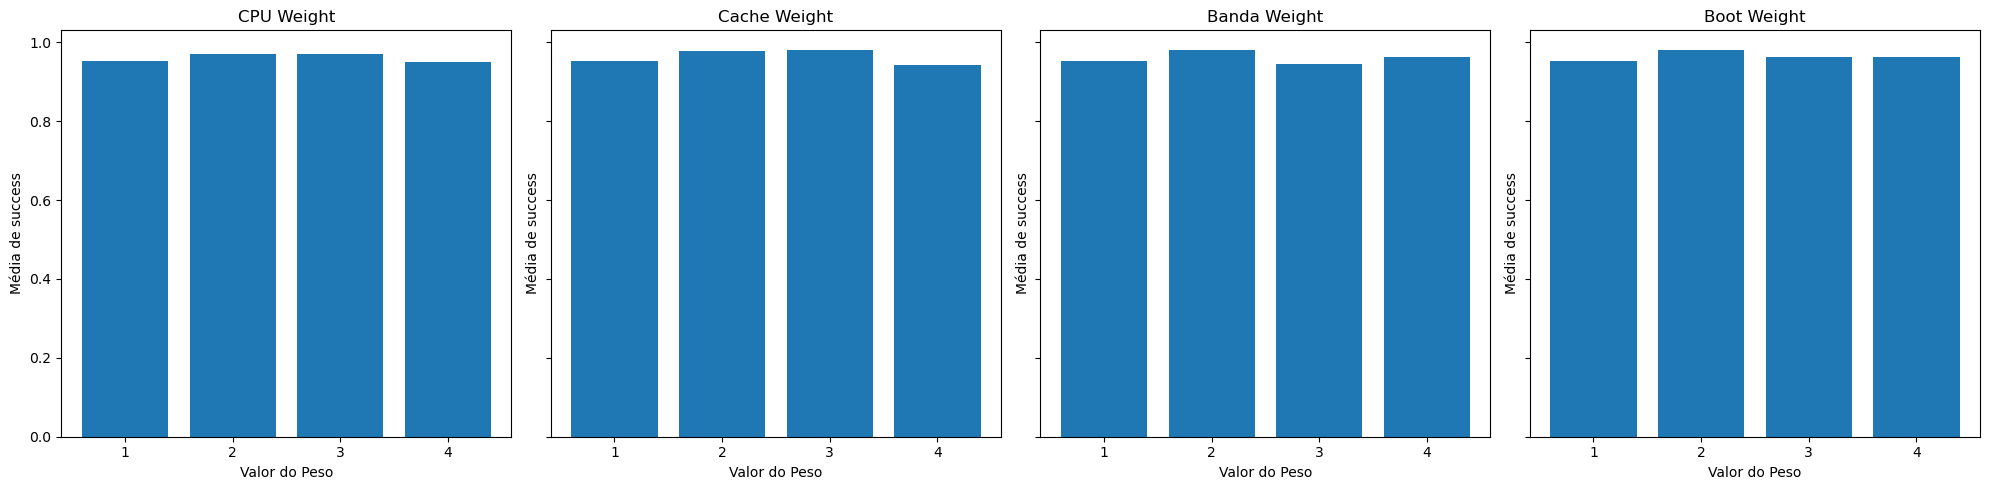

Analisando a métrica: latency


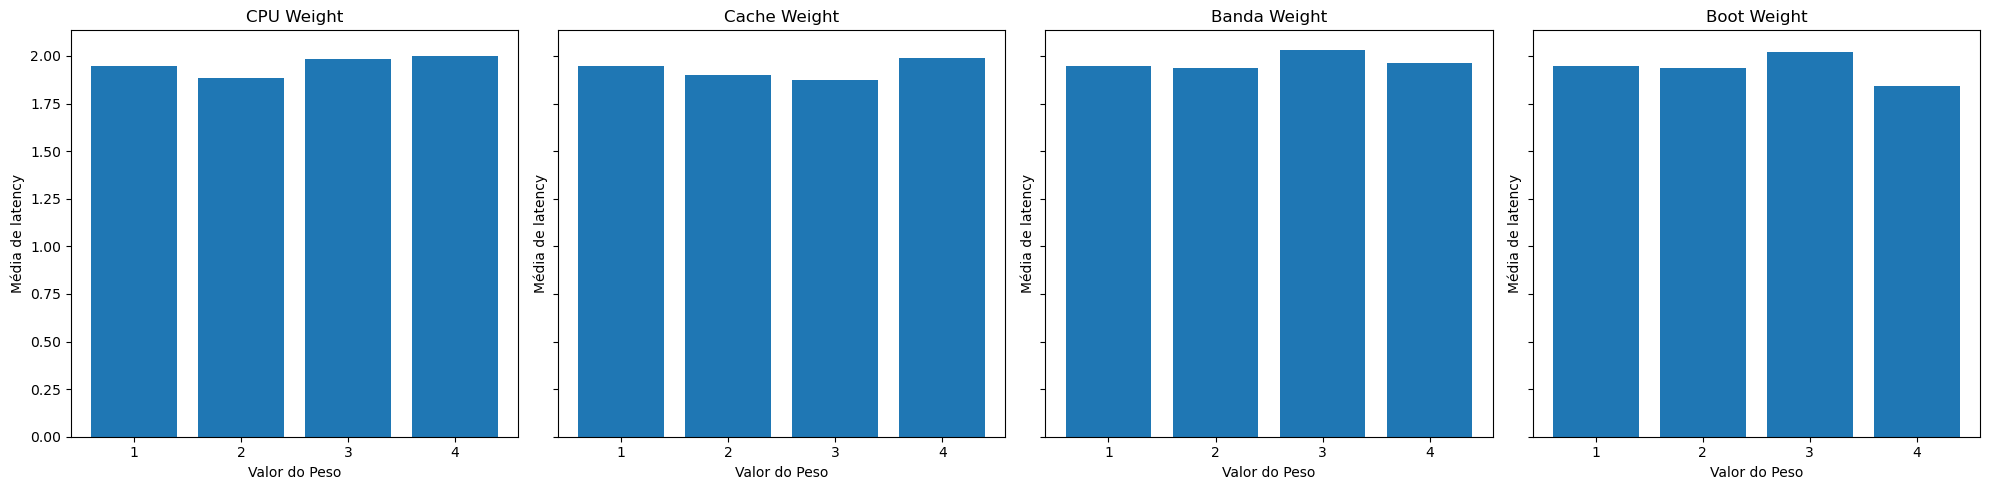

Analisando a métrica: duration


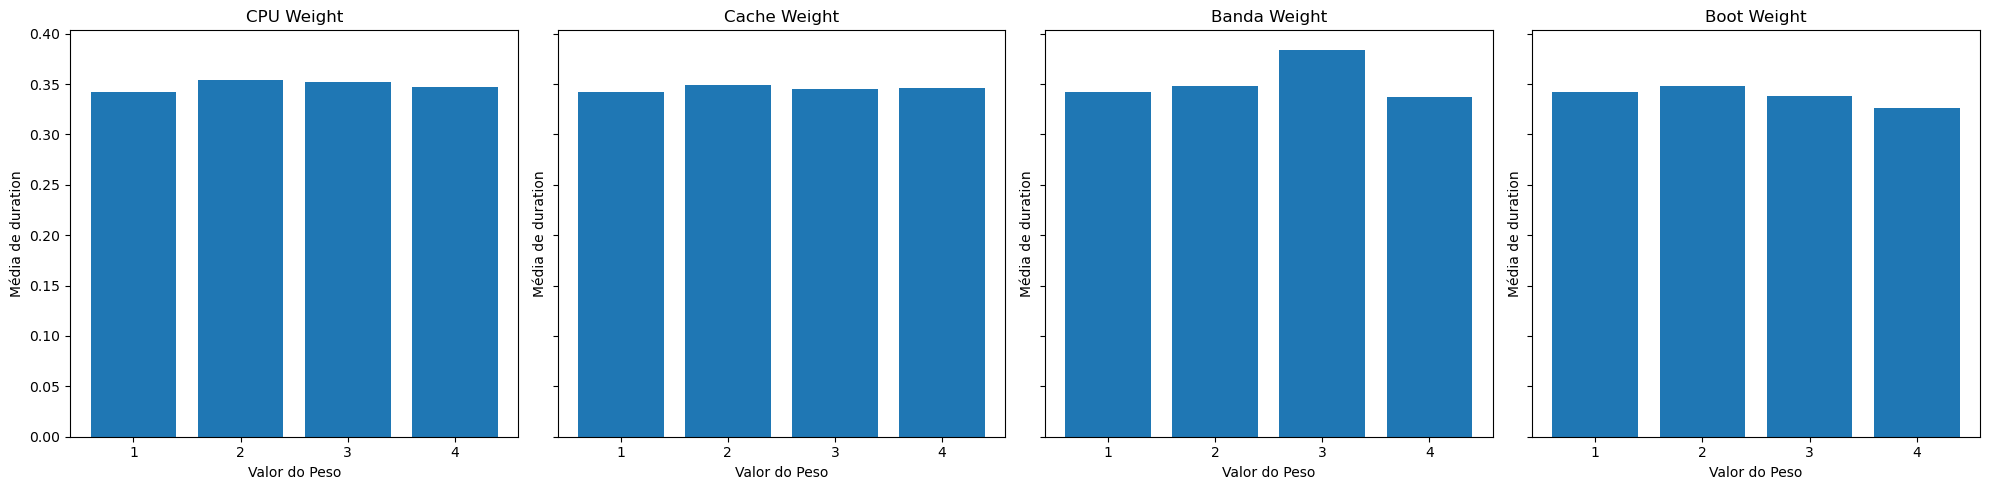

Analisando a métrica: running_sfcs


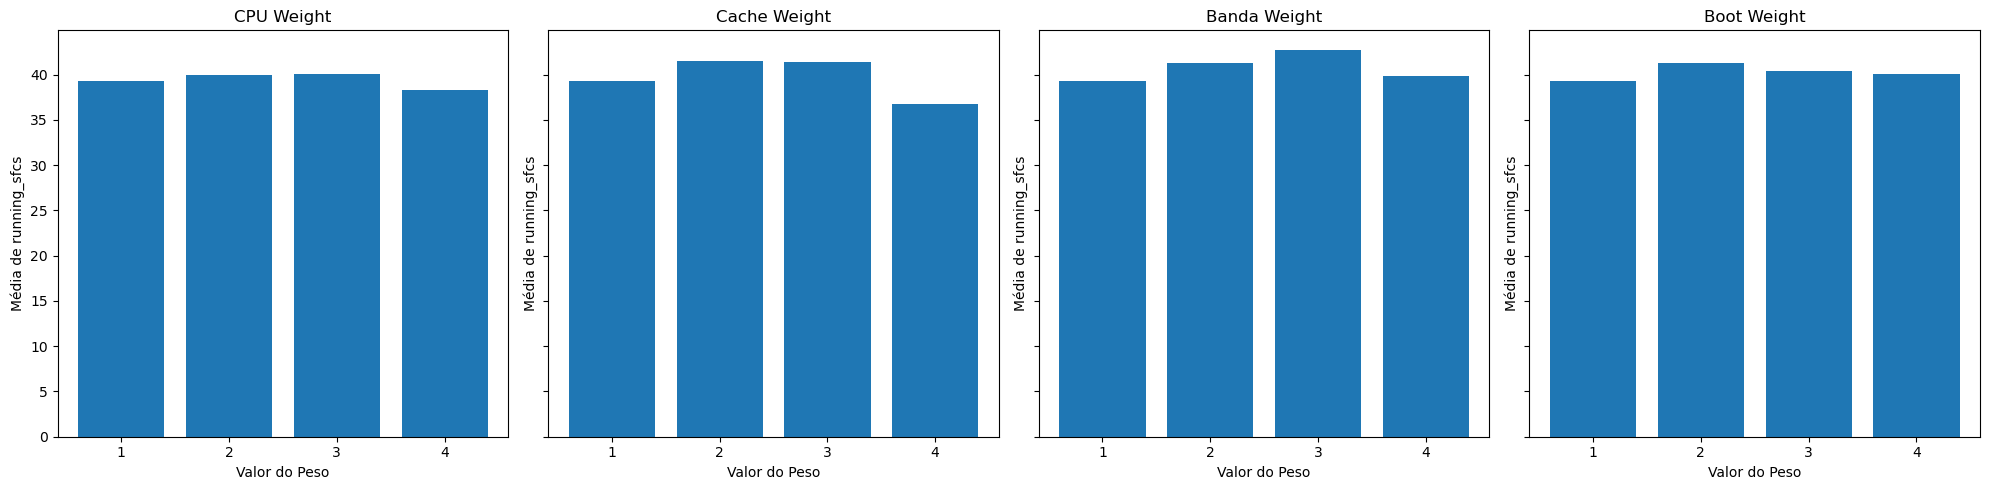

Analisando a métrica: cpu_saved


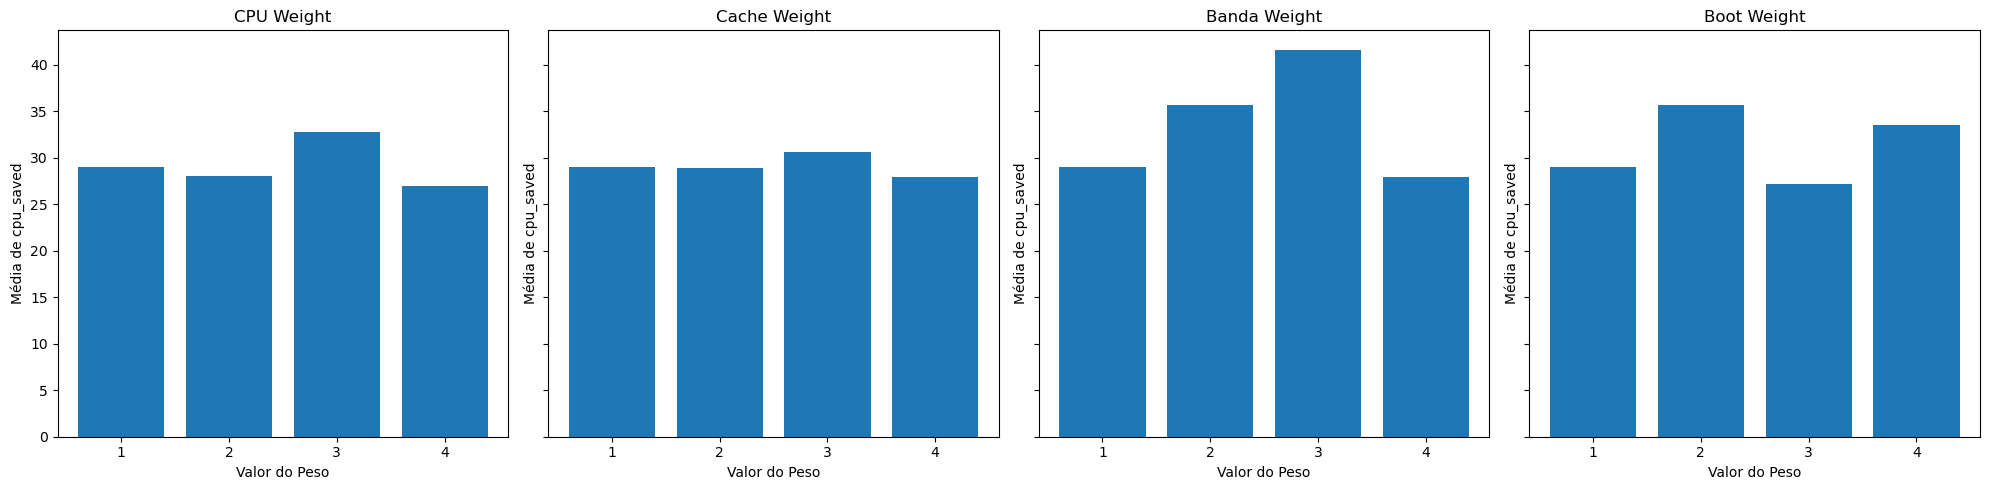

Analisando a métrica: cache_saved


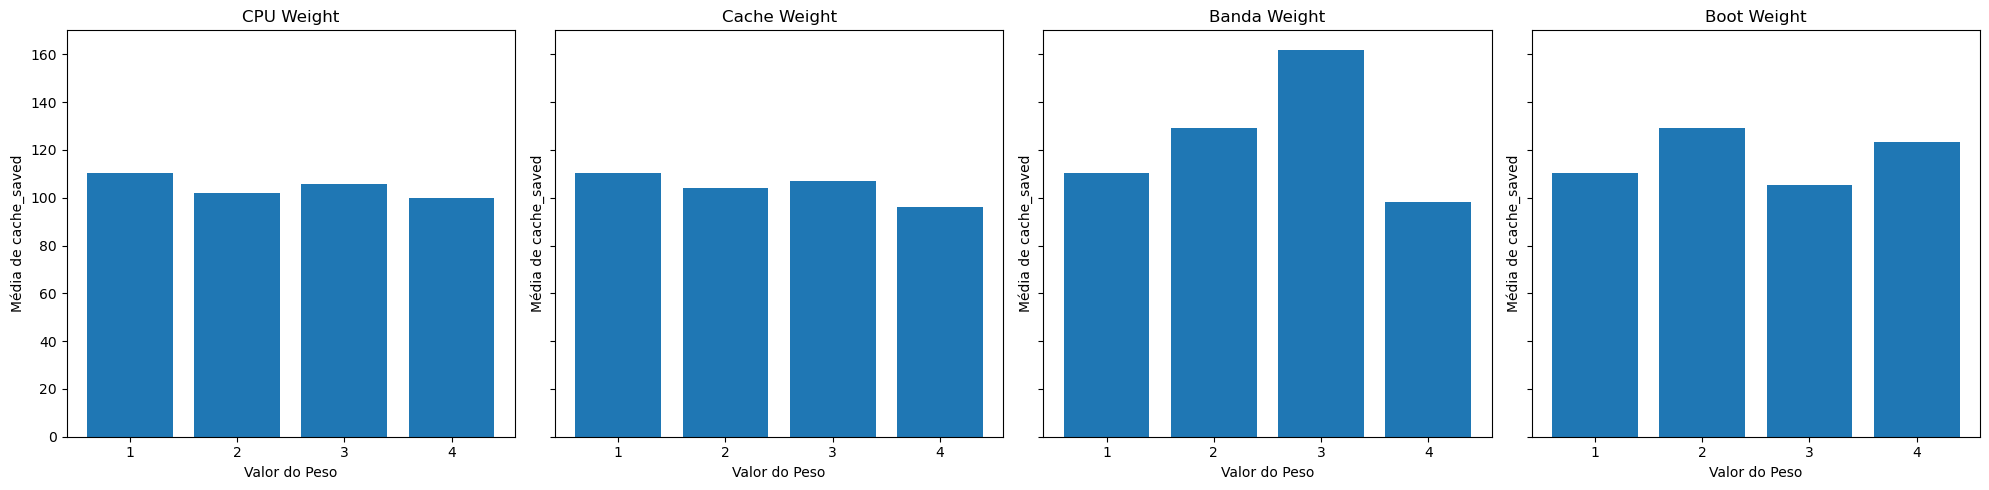

Analisando a métrica: shared_vnfs


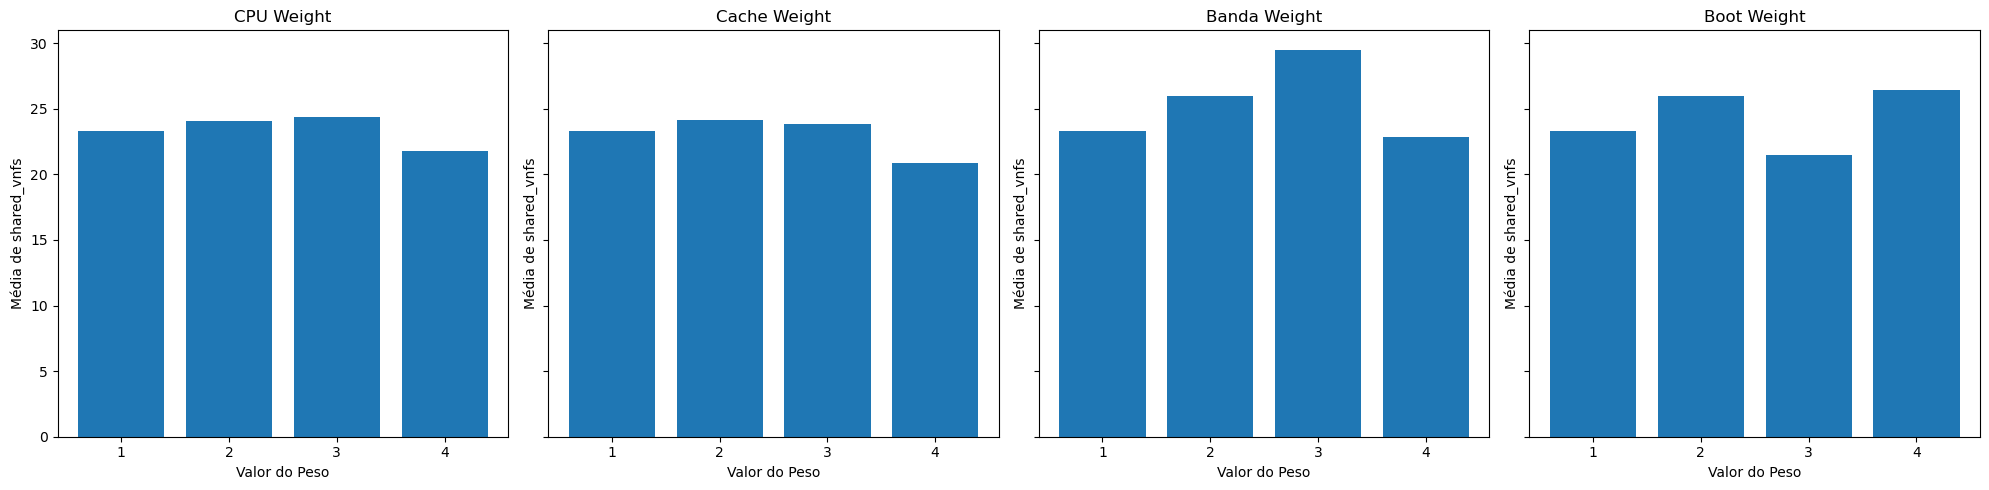

Analisando a métrica: Latency


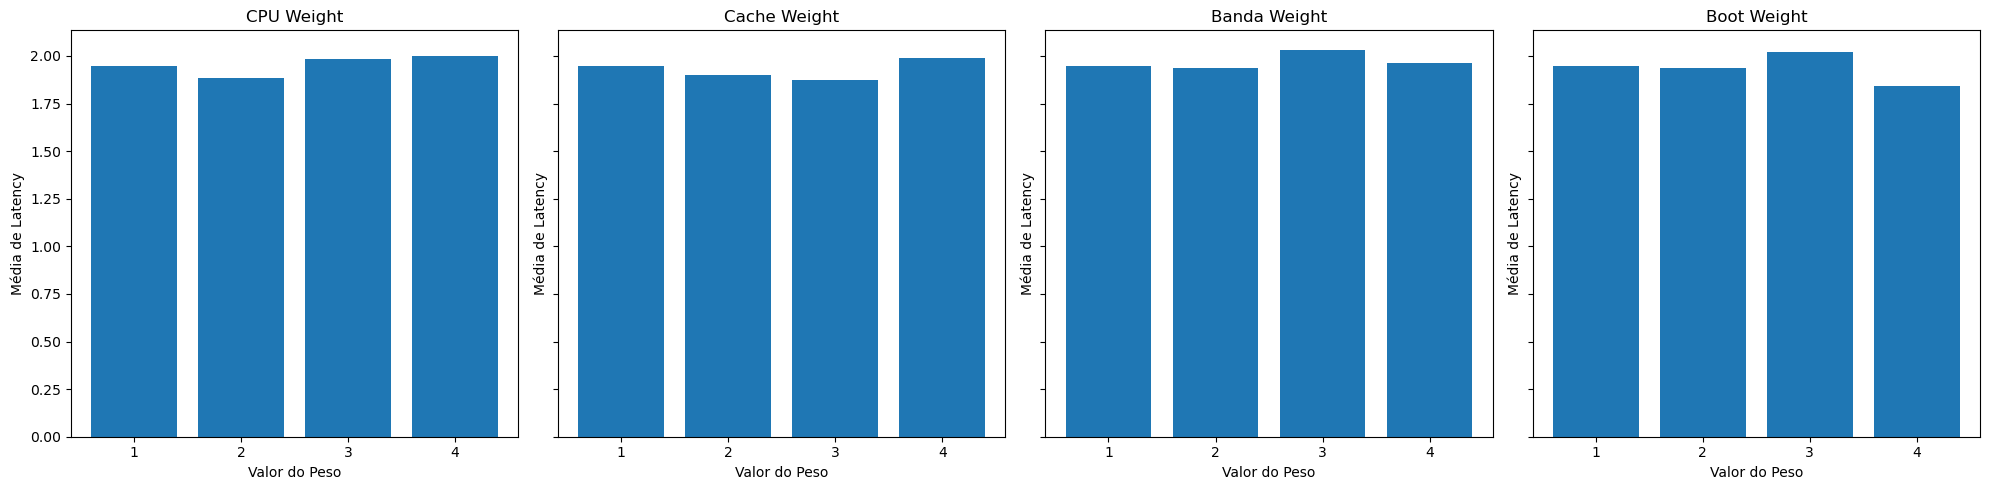

Analisando a métrica: eficiencia de cpu


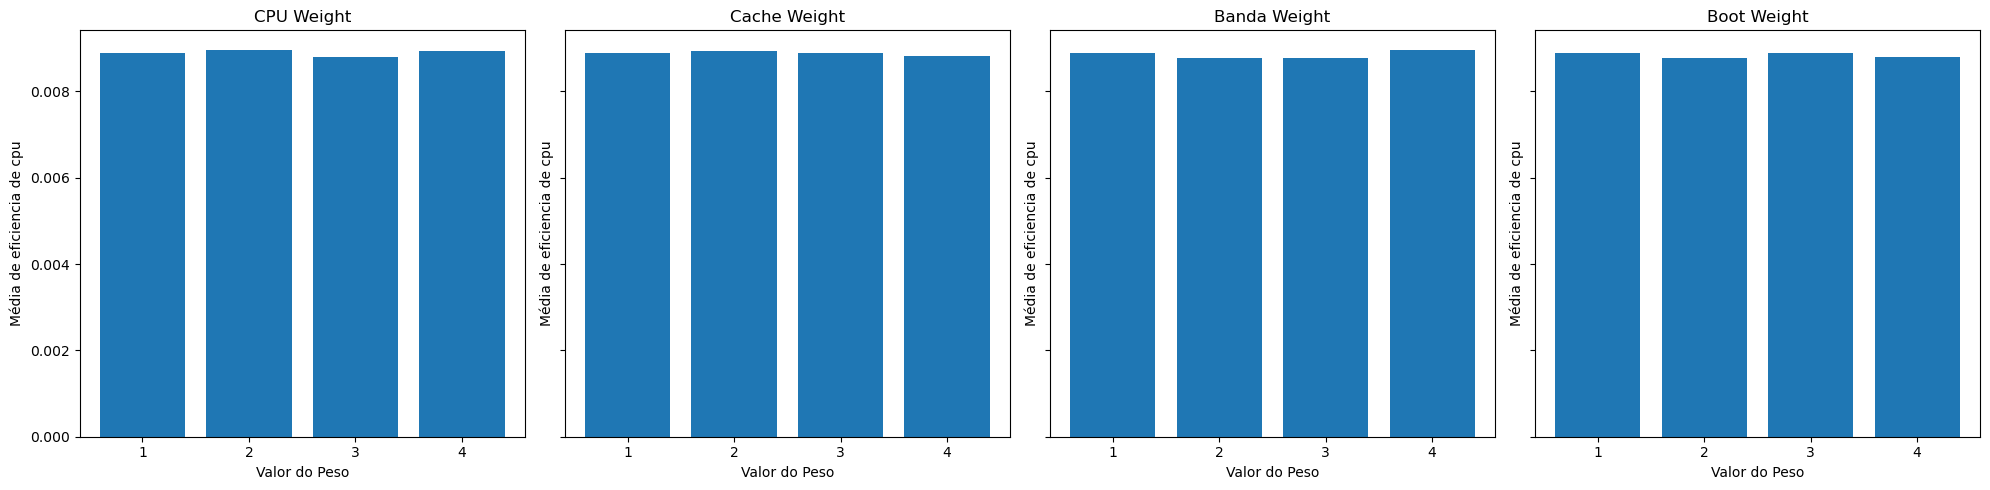

Analisando a métrica: eficiencia de banda


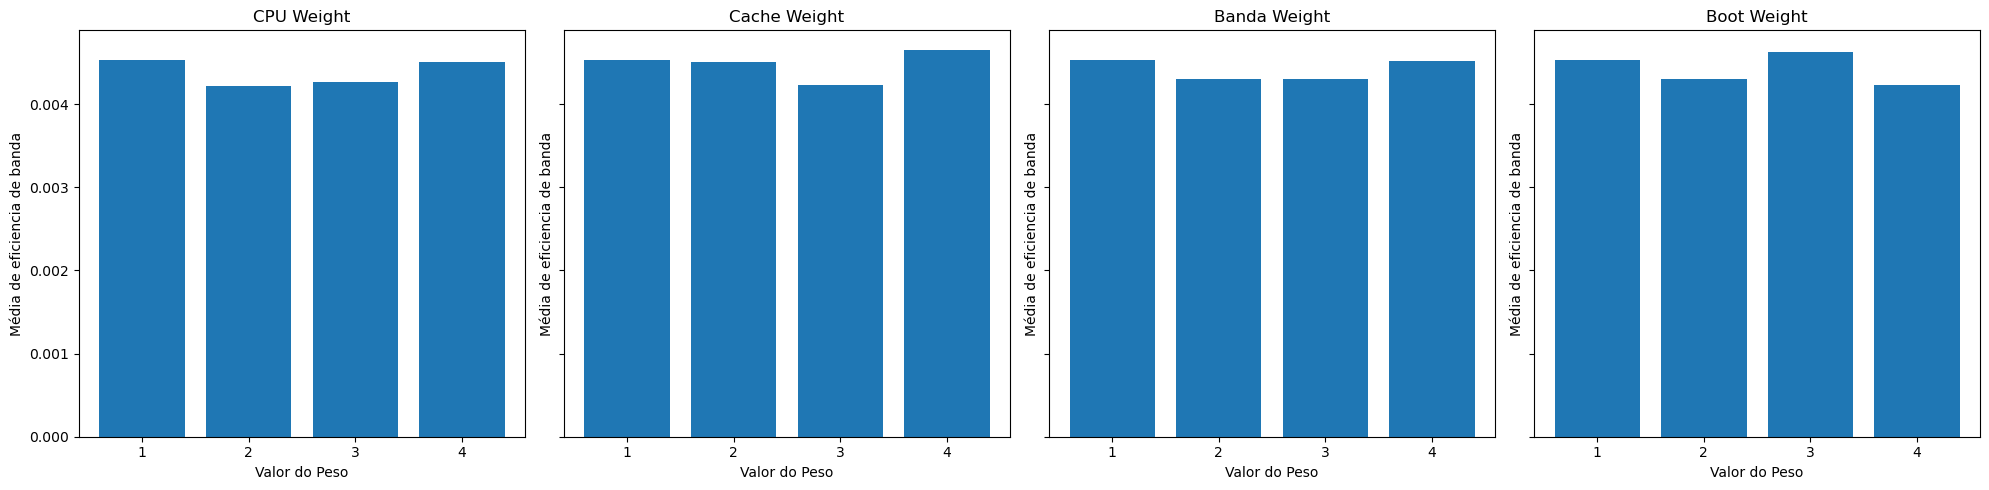

Analisando a métrica: eficiencia de cache


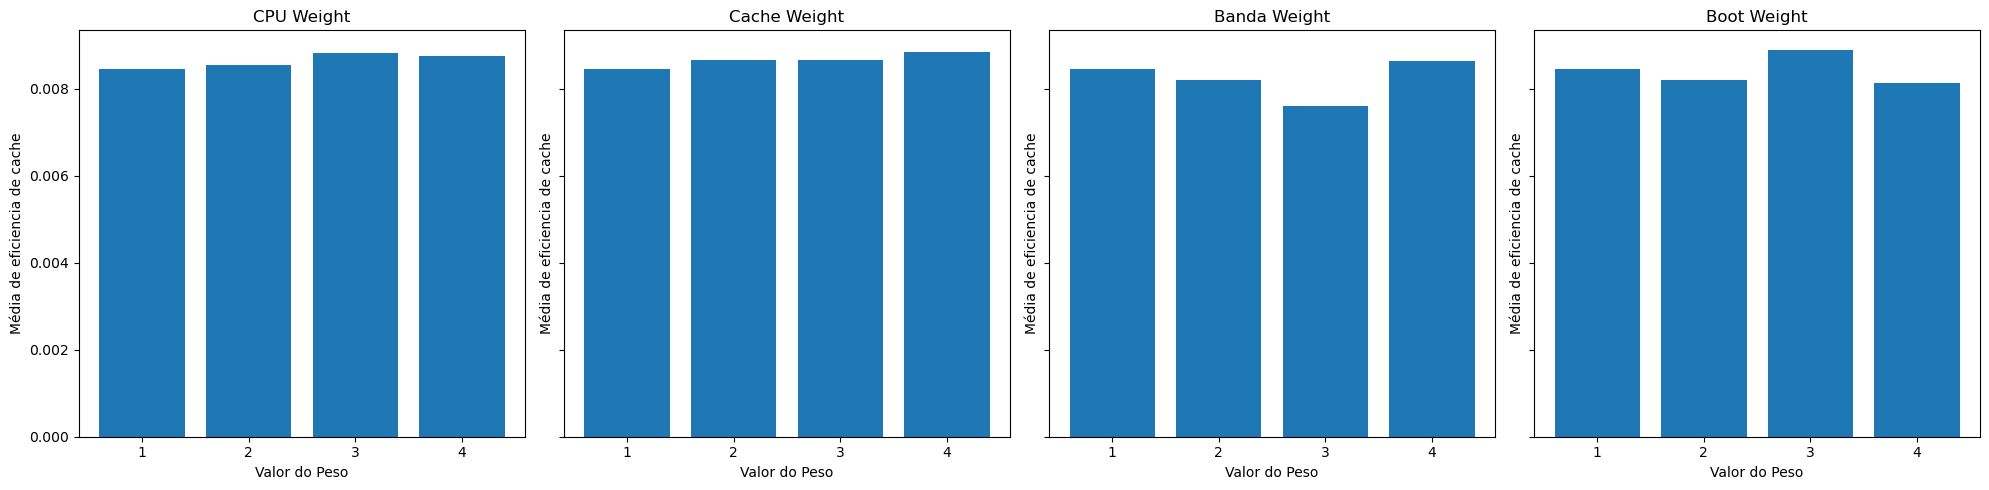

Analisando a métrica: bit_rate


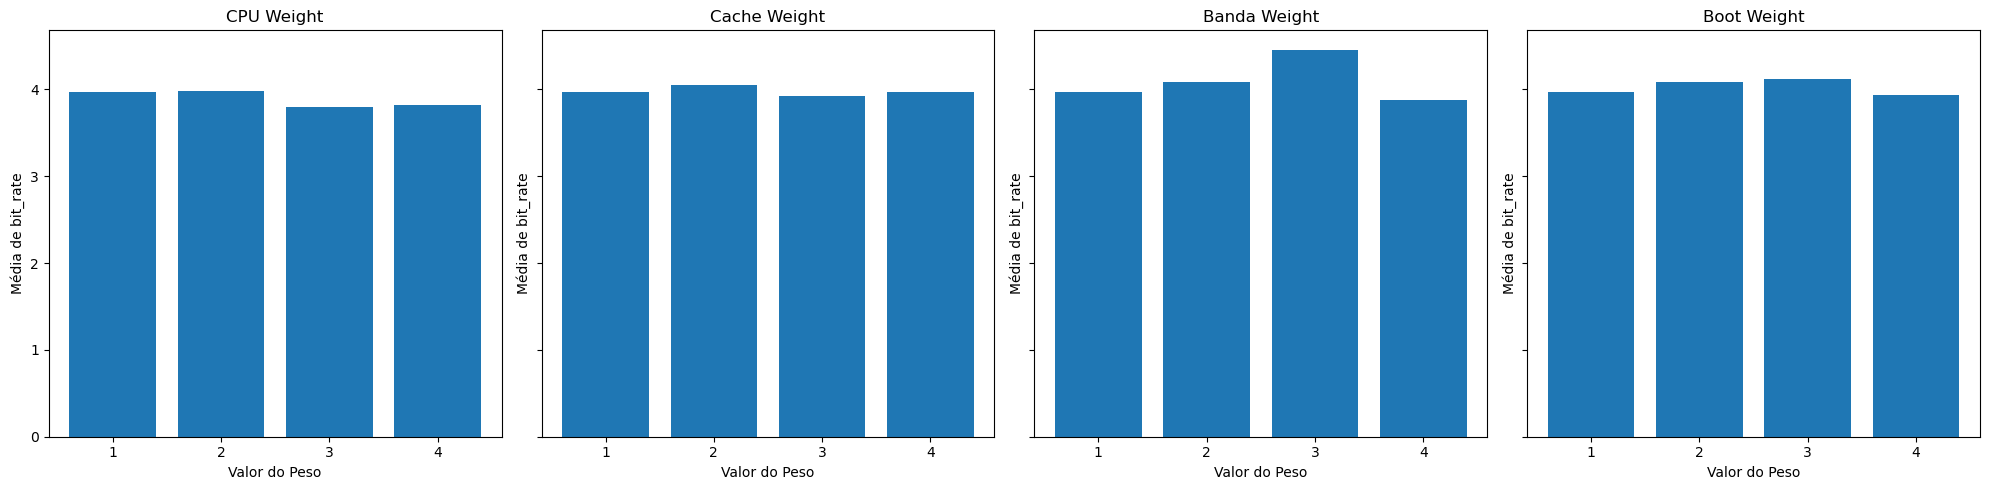

In [13]:
import matplotlib.pyplot as plt

pesos_nomes = {1: "CPU Weight", 2: "Cache Weight", 3: "Banda Weight", 4: "Boot Weight"}


def analisar_media_por_peso(df, coluna, pesos_nomes):
    # Calculando a média para a coluna especificada, para cada valor de cada peso
    media_por_peso = df.groupby(["Peso", "ValorPeso"])[coluna].mean().unstack()

    # Renomeando os índices conforme o dicionário de nomes de pesos
    media_por_peso_renomeado = media_por_peso.rename(index=pesos_nomes)

    # Criando gráficos de barras para cada peso
    fig, ax = plt.subplots(1, len(pesos_nomes), figsize=(20, 5), sharey=True)
    for i, peso_nome in enumerate(pesos_nomes.values()):
        ax[i].bar(media_por_peso_renomeado.columns, media_por_peso_renomeado.iloc[i])
        ax[i].set_title(f"{peso_nome}")
        ax[i].set_xlabel("Valor do Peso")
        ax[i].set_ylabel(f"Média de {coluna}")
        ax[i].set_xticks(range(1, len(media_por_peso_renomeado.columns) + 1))

    plt.tight_layout()
    plt.show()


# Lista das métricas especificadas
metricas = [
    "cpu_utilization",
    "cache_utilization",
    "bandwidth_utilization",
    "success",
    "latency",
    "duration",
    "running_sfcs",
    "cpu_saved",
    "cache_saved",
    "shared_vnfs",
    "Latency",
    "eficiencia de cpu",
    "eficiencia de banda",
    "eficiencia de cache",
    "bit_rate",
]

# Iterando sobre a lista de métricas para aplicar a função
for metrica in metricas:
    try:
        # Aplica a função para cada métrica
        print(f"Analisando a métrica: {metrica}")
        analisar_media_por_peso(df_expandido, metrica, pesos_nomes)
    except Exception as e:
        # Caso ocorra algum erro com a métrica específica, imprime o erro
        print(f"Erro ao analisar a métrica {metrica}: {e}")

# Melhor configuração

In [14]:
grouped_big_data

,parameters,tempo,practical_cpu_utilization,cpu_utilization,cache_utilization,bandwidth_utilization,practical_bandwidth_utilization,practical_cache_utilization,success,latency,duration,running_sfcs,cpu_saved,cache_saved,shared_vnfs,Latency,eficiencia de cpu,eficiencia de banda,eficiencia de cache,bit_rate
0,"[1, 1, 1, 1]",499.5,0.374216,0.348560,0.331642,0.177506,0.397055,0.419325,0.953363,1.944917,0.341880,39.294033,29.003250,110.506250,23.299917,1.944917,0.008876,0.004531,0.008442,3.970551
1,"[1, 1, 1, 2]",499.5,0.379635,0.357411,0.340269,0.168187,0.398127,0.435493,0.971277,1.886667,0.354568,39.949367,28.094694,101.939583,24.068833,1.886667,0.008949,0.004217,0.008554,3.981265
2,"[1, 1, 1, 3]",499.5,0.370614,0.350386,0.350006,0.169508,0.379889,0.435663,0.969372,1.986400,0.351991,40.027167,32.761194,105.868750,24.399167,1.986400,0.008795,0.004270,0.008812,3.798894
3,"[1, 1, 1, 4]",499.5,0.368898,0.339273,0.333724,0.170774,0.381609,0.434102,0.951076,2.000850,0.347229,38.257767,27.008000,100.025000,21.765817,2.000850,0.008928,0.004512,0.008744,3.816087
4,"[1, 1, 2, 1]",499.5,0.384065,0.370415,0.359347,0.185261,0.404921,0.441208,0.976687,1.898167,0.349384,41.530667,28.954444,103.916667,24.138250,1.898167,0.008923,0.004507,0.008656,4.049212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,"[3, 3, 4, 2]",499.5,0.380923,0.368074,0.363683,0.179537,0.377255,0.455135,0.982269,2.022183,0.201253,41.349850,27.378361,102.414583,23.439817,2.022183,0.008910,0.004343,0.008854,3.772549
168,"[3, 3, 4, 3]",499.5,0.372625,0.358549,0.352332,0.173749,0.376863,0.435074,0.971074,2.055367,0.197810,40.517683,29.258672,105.362083,23.344783,2.055367,0.008848,0.004295,0.008698,3.768631
169,"[3, 3, 4, 4]",499.5,0.355366,0.337846,0.336721,0.168231,0.385418,0.422720,0.960695,1.923517,0.199707,38.725017,31.209889,108.779167,23.956950,1.923517,0.008726,0.004366,0.008685,3.854177
170,"[3, 4, 1, 1]",499.5,0.383200,0.358924,0.350830,0.169019,0.386418,0.435286,0.969590,2.031317,0.202335,40.311500,26.623167,103.554167,23.238417,2.031317,0.008900,0.004181,0.008705,3.864182


In [15]:

df = grouped_big_data

# Convertendo a lista de parâmetros em uma string para facilitar a visualização
df["parameters_str"] = grouped_big_data["parameters"].apply(lambda x: "-".join(map(str, x)))

# Removendo a coluna duplicada 'Latency'
df = df.drop(columns=["latency"])

import plotly.express as px

# Lista de métricas para visualização
metrics = [
    "success",
    "cpu_utilization",
    "cache_utilization",
    "bandwidth_utilization",
    "bit_rate",
    "Latency",
    "eficiencia de cpu",
    "eficiencia de banda",
    "eficiencia de cache",
    "cpu_saved",
    "cache_saved",
    "shared_vnfs",
]

# Loop para criar um gráfico para cada métrica
for metric in metrics:
    # Verificando se a métrica existe no DataFrame
    if metric in df.columns:
        fig = px.bar(df, x="parameters_str", y=metric, title=metric)
        fig.update_xaxes(title_text="Parameters String")
        fig.update_yaxes(title_text=metric)
        fig.show()